# Run matched filters in EMIT product

**Author**: Gonzalo Mateo-García

Example from work:
>  V. Růžička, G. Mateo-Garcia, L. Gómez-Chova, A. Vaughan, L. Guanter, and A. Markham, [Semantic segmentation of methane plumes with hyperspectral machine learning models](https://www.nature.com/articles/s41598-023-44918-6). _Scientific Reports 13, 19999_ (2023). DOI: 10.1038/s41598-023-44918-6.

```
pip install "marshsi[mag1c]"
```

## Step 1: download EMIT image

In order to download and process the EMIT image we will use the emit reader in the [georeader](https://github.com/spaceml-org/georeader/) package. See [this tutorial](https://spaceml-org.github.io/georeader/emit_explore/) for an example of how to load and plot the data.

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt

EMIT_FILENAME = "../tests/data/EMIT_L1B_RAD_001_20220827T060753_2223904_013.nc"

NEED_DOWNLOAD = not os.path.exists(EMIT_FILENAME)
print(f"File '{EMIT_FILENAME}' exists: {not NEED_DOWNLOAD}")

File '../tests/data/EMIT_L1B_RAD_001_20220827T060753_2223904_013.nc' exists: False


In [9]:
import georeader
from georeader.readers import emit, download_utils
from georeader import plot

if NEED_DOWNLOAD:
    link = emit.get_radiance_link(EMIT_FILENAME)

    earthdata_nasa_account = True

    # NASA's data archive requires creating an account for downloading EMIT files directly.
    # Create an user and a token at the NASA Earthdata portal (https://urs.earthdata.nasa.gov/profile)

    if earthdata_nasa_account:
        emit.AUTH_METHOD = "token"
        emit.TOKEN = "ey..." # copy your token here
        headers = {"Authorization": f"Bearer {emit.TOKEN}"}
        
        product = download_utils.download_product(link, headers=headers, verify=True,
                                                 filename=EMIT_FILENAME)
    else:
        # alternatively for the sake of this demo, we also uploaded this scene on our gdrive
        # (but if these two files are missing, please use the above download instead)
        import subprocess
        subprocess.run(["gdown", "1jyFejO80Q82qUZ5tRPaDTqsBHefuXYa0"], check=True)
        subprocess.run(["gdown", "1a9k2YZDXfa4g95KlqCcKfkYcaA-QegYU"], check=True)
else:
    print(f"Skipping download, '{EMIT_FILENAME}' already exists")

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1.85G/1.85G [01:22<00:00, 22.4MiB/s]


In [10]:
rst = emit.EMITImage(EMIT_FILENAME)
rst

 
         File: ../tests/data/EMIT_L1B_RAD_001_20220827T060753_2223904_013.nc
         Transform: | 0.00,-0.00, 61.16|
|-0.00,-0.00, 36.83|
| 0.00, 0.00, 1.00|
         Shape: (285, 2007, 2239)
         Resolution: (0.0005422325202530942, 0.0005422325202530942)
         Bounds: (np.float64(61.1592142222353), np.float64(35.74201728362127), np.float64(62.3732728350893), np.float64(36.8302779517758))
         CRS: EPSG:4326
         units: uW/cm^2/SR/nm
        

## Run mag1c retrieval on the EMIT product

Run mag1c filter retrieval based on the work of [Foote et al. 2020](https://ieeexplore.ieee.org/document/9034492).

In [11]:
from marshsi.emit import mag1c_emit

mfoutput, albedo = mag1c_emit.mag1c_emit(rst, column_step=4, georeferenced=False)
mfoutput

/mnt/batch/tasks/shared/LS_root/mounts/clusters/gonzvml2/code/Users/adm.gmateoga/marshsi/marshsi/emit/mag1c.py:115: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  response = np.divide(
/mnt/batch/tasks/shared/LS_root/mounts/clusters/gonzvml2/code/Users/adm.gmateoga/marshsi/marshsi/emit/mag1c.py:121: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  lograd = np.log(resampled, where=resampled > 0)  # (7, K)
	Running mag1c filter by columns: 100%|██████████████████████████████████████████████████████████████████████████████████████████████| 311/311 [00:14<00:00, 20.80it/s]


array([[  0.     ,   0.     ,   0.     , ...,   0.     ,   0.     ,
          0.     ],
       [  0.     ,   0.     ,   0.     , ...,   0.     ,   0.     ,
          0.     ],
       [395.65817,   0.     ,   0.     , ...,   0.     ,   0.     ,
          0.     ],
       ...,
       [  0.     ,   0.     ,   0.     , ...,   0.     ,   0.     ,
        363.98874],
       [  0.     ,   0.     ,   0.     , ...,   0.     ,   0.     ,
          0.     ],
       [  0.     ,   0.     ,   0.     , ...,   0.     ,   0.     ,
          0.     ]], shape=(1280, 1242), dtype=float32)

Plot results on satellite coordinates:

<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:3: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_73250/1736185905.py:3: SyntaxWarning: invalid escape sequence '\D'
  ax[0].set_title("$\Delta$CH$_4$ [ppm x m]")


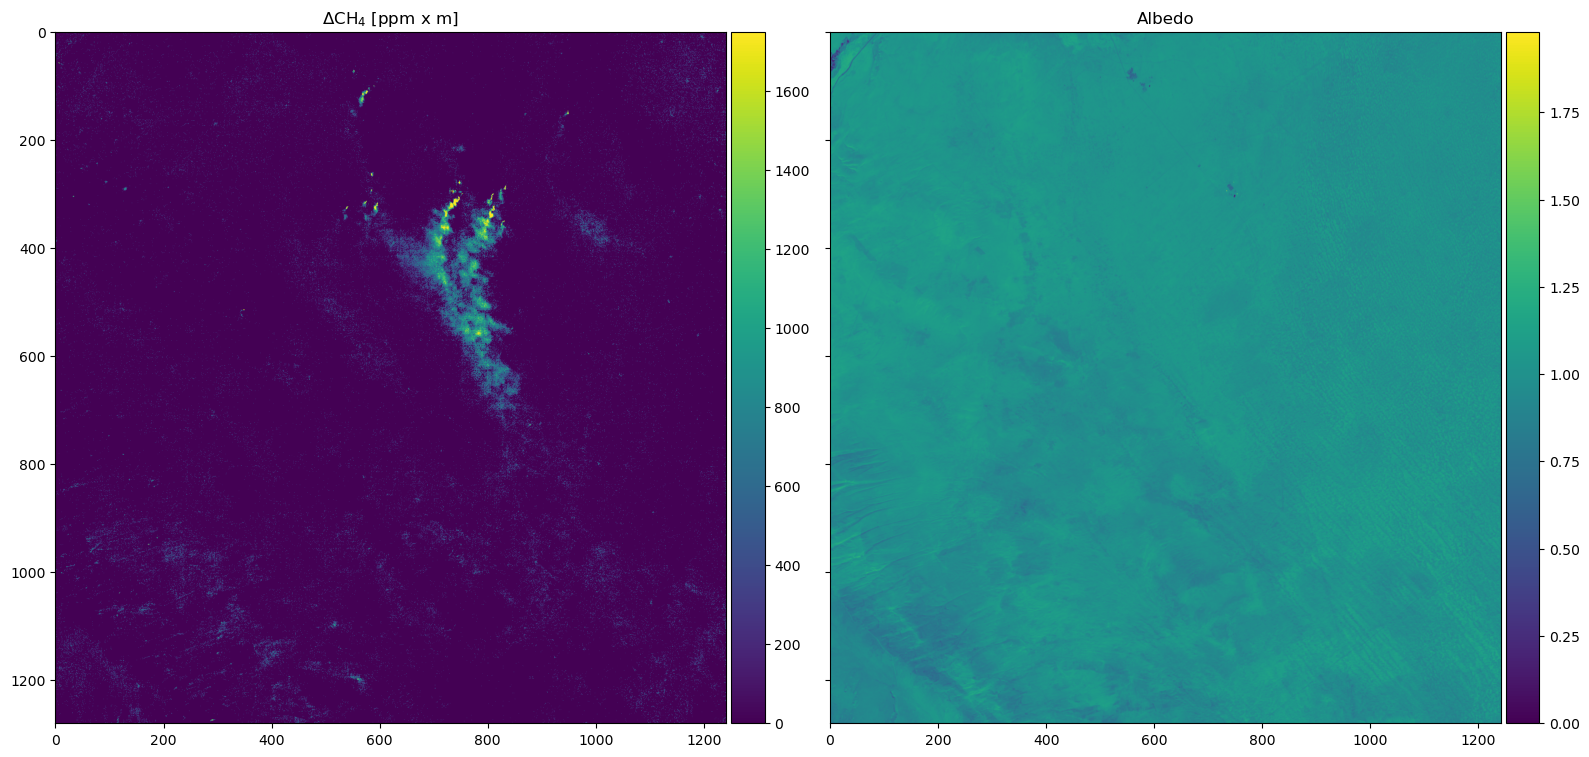

In [12]:
fig, ax = plt.subplots(1,2, figsize=(16,8), tight_layout=True, sharey=True)
im = ax[0].imshow(mfoutput, vmin=0,vmax=1750)
ax[0].set_title("$\Delta$CH$_4$ [ppm x m]")
plot.colorbar_next_to(im, ax[0])

im = ax[1].imshow(albedo, vmin=0)
ax[1].set_title("Albedo")
plot.colorbar_next_to(im, ax[1])

## Run WMF retrieval on EMIT product

Run wide matched filter retrieval based on the work of [Roger et al. 2024](https://doi.org/10.5194/amt-17-1333-2024).

In [13]:
from marshsi.emit import retrieval_upv_emit


mf_classic, mf_extended, mf_combo, mf_extended_filtered, rad = retrieval_upv_emit.AT_MF_total_EMIT(rst, georeferenced=False) # georreferenced=False

Plot results on satellite coordinates:

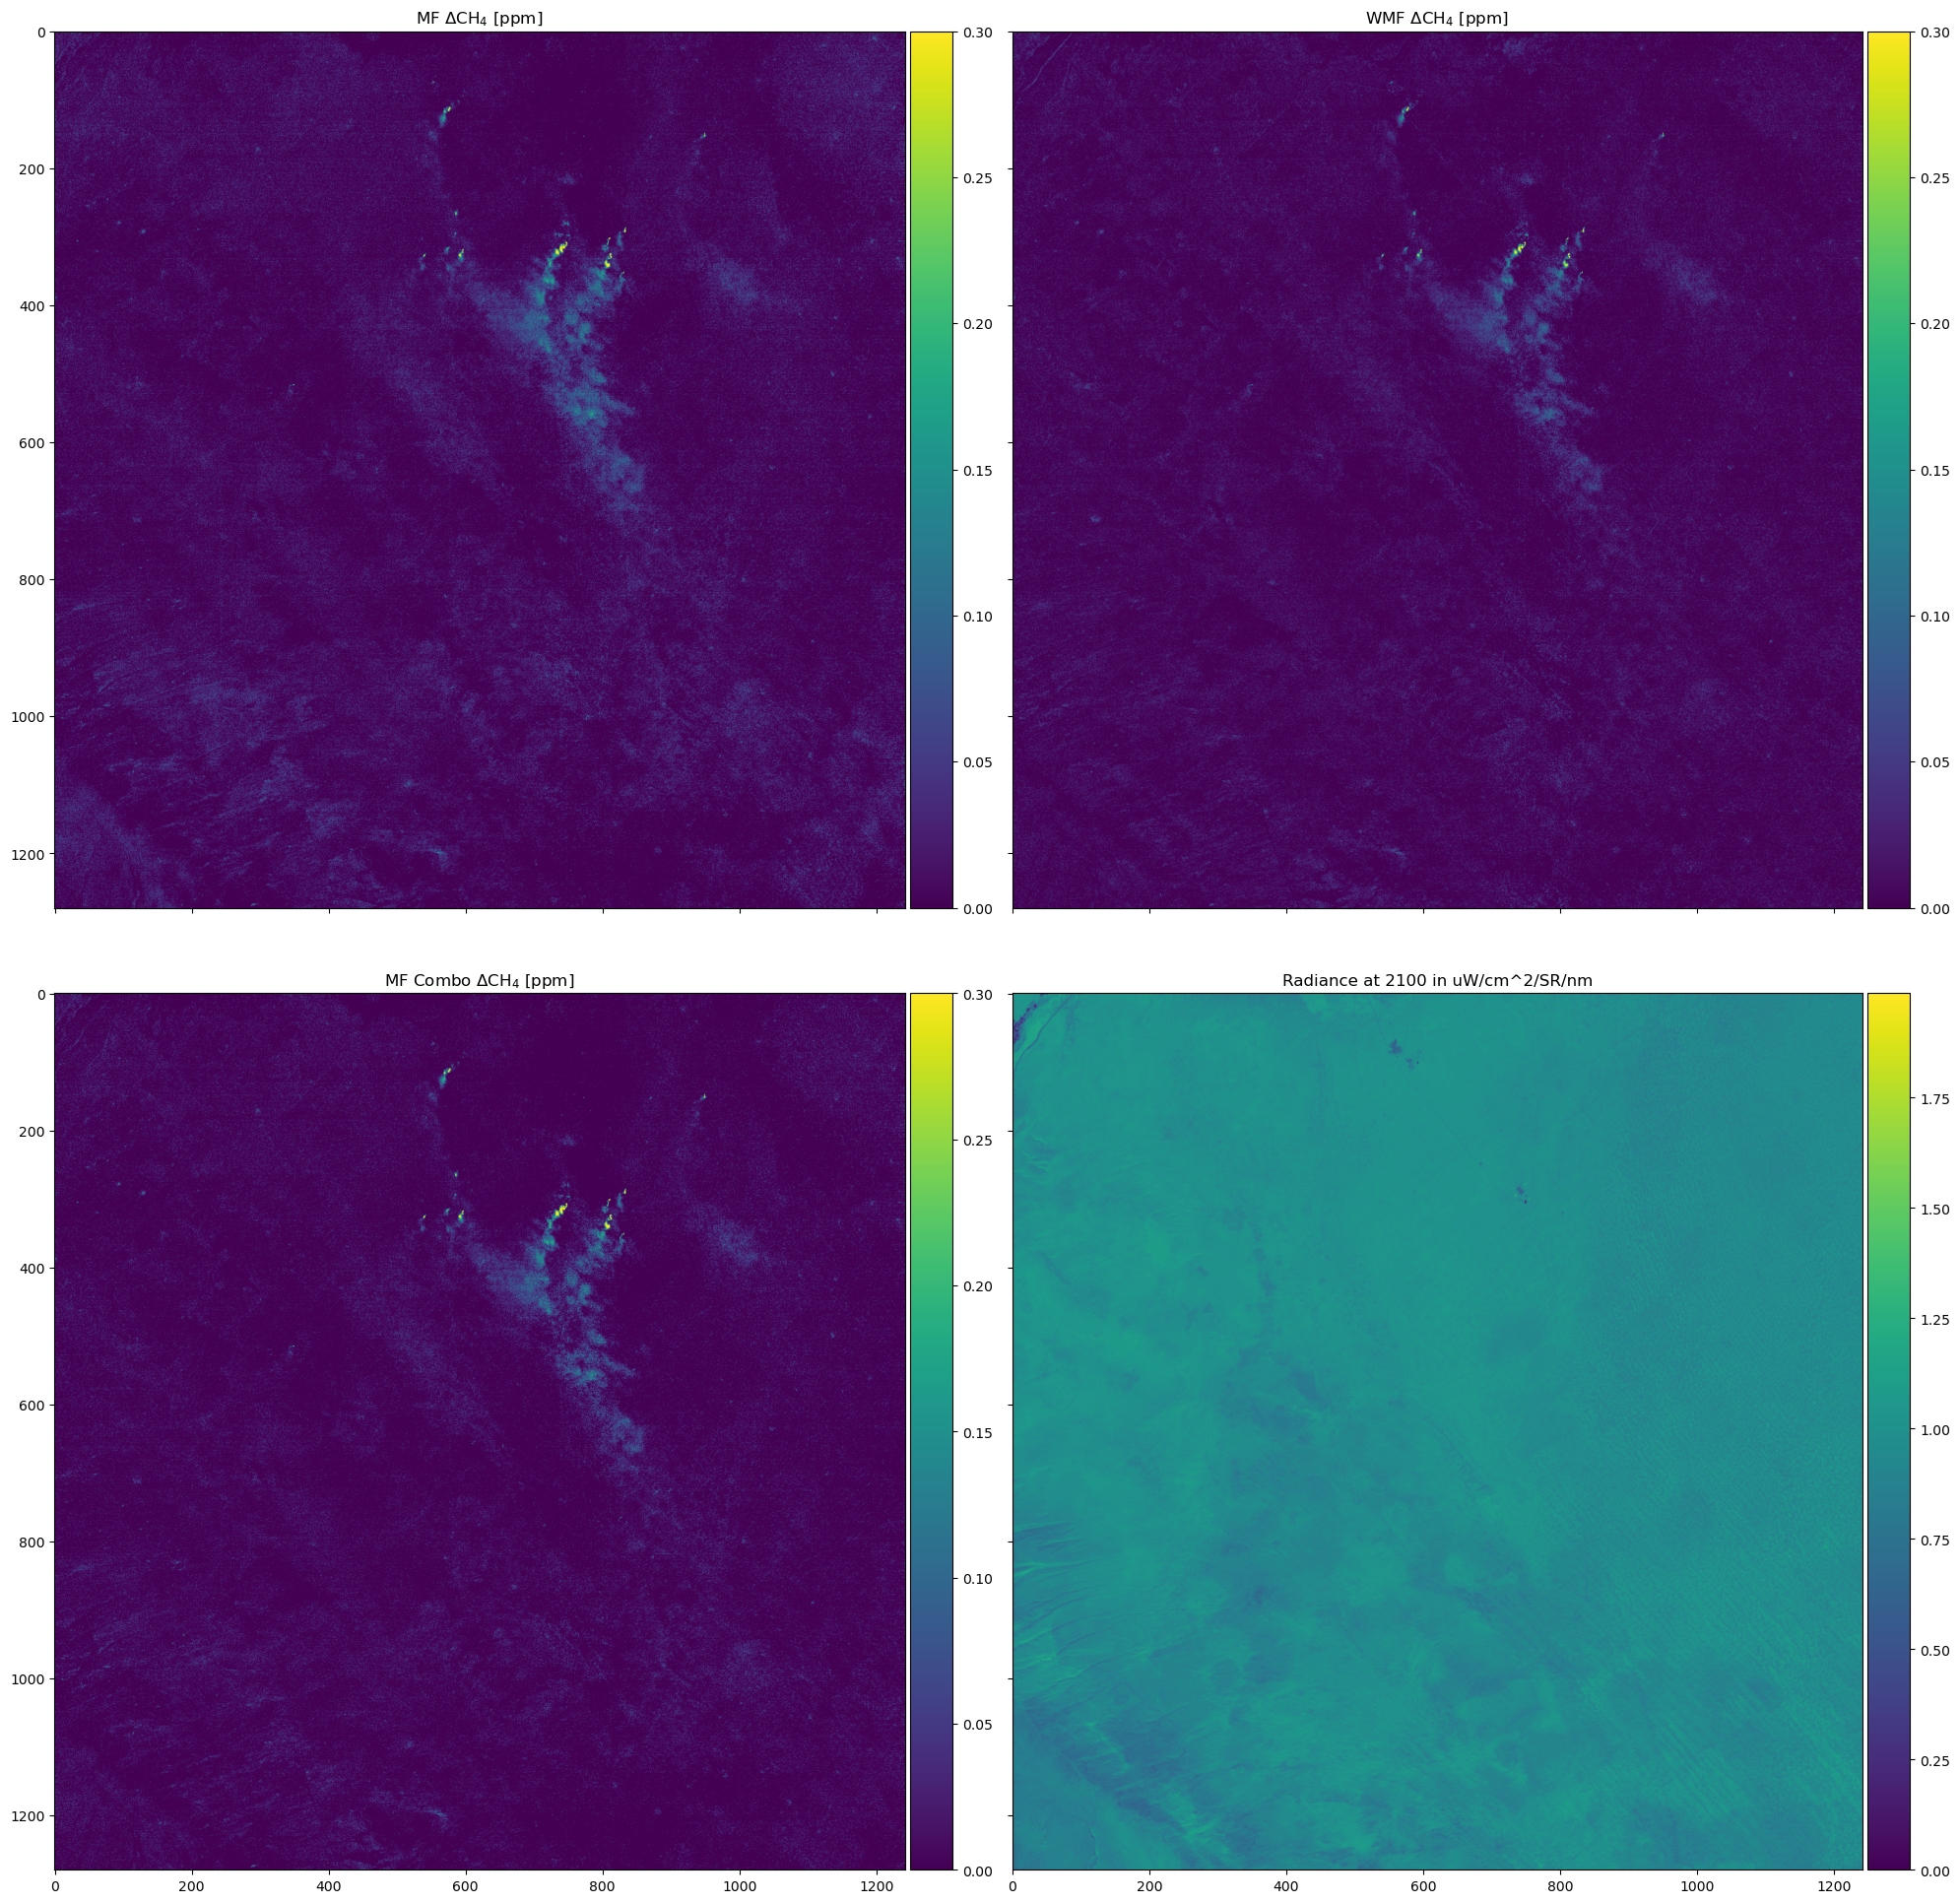

In [22]:
fig, ax = plt.subplots(2,2, figsize=(20,20), tight_layout=True, sharey=True, sharex=True)

axi = ax[0,0]
im = axi.imshow(mf_classic, vmin=0,vmax=0.3)
axi.set_title(r"MF $\Delta$CH$_4$ [ppm]")
plot.colorbar_next_to(im, axi)

axi = ax[0,1]
im = axi.imshow(mf_extended, vmin=0,vmax=0.3)
axi.set_title(r"WMF $\Delta$CH$_4$ [ppm]")
plot.colorbar_next_to(im, axi)

axi = ax[1,0]
im = axi.imshow(mf_combo, vmin=0,vmax=0.3)
axi.set_title(r"MF Combo $\Delta$CH$_4$ [ppm]")
plot.colorbar_next_to(im, axi)

# rad
axi = ax[1,1]
im = axi.imshow(rad, vmin=0)
axi.set_title(f"Radiance at {retrieval_upv_emit.RAD_WAVELENGTH} in {rst.units}")
plot.colorbar_next_to(im, axi)

## Georreference to UTM

/anaconda/envs/marsmlpy312_dev/lib/python3.12/site-packages/georeader/reflectance.py:219: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  response = np.divide(response, response.sum(axis=0), where=response.sum(axis=0) > 0)# (N, K)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-9999.0..1.0].


<Axes: title={'center': 'WMF $\\Delta X$CH$_4$ [ppm]'}>

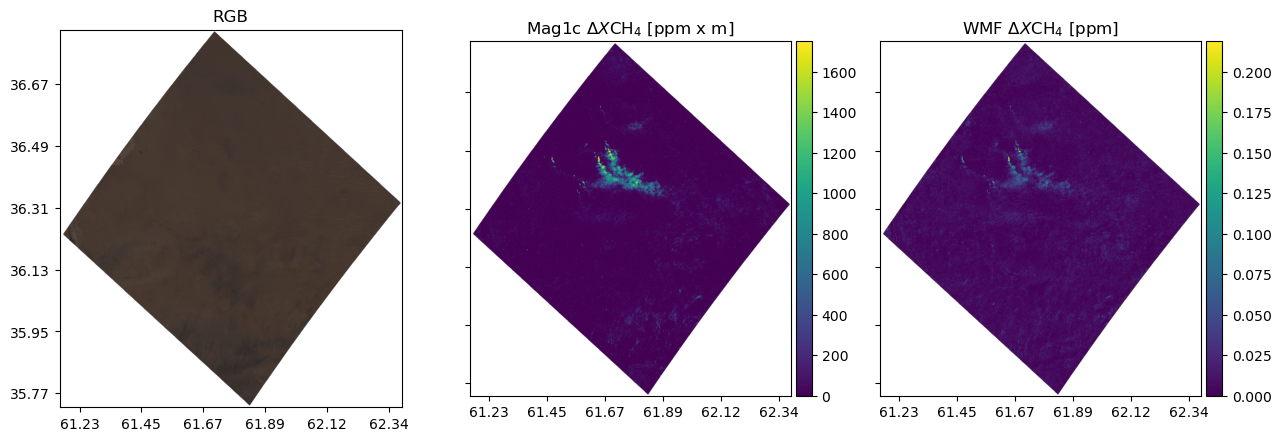

In [23]:
crs_utm = georeader.get_utm_epsg(rst.footprint("EPSG:4326"))
emit_image_utm = rst.to_crs(crs_utm)

rgb = emit_image_utm.load_rgb(as_reflectance=True)

fig, ax = plt.subplots(1,3, figsize=(15,5), sharey=True)

mag1c_geo = emit_image_utm.georreference(mfoutput, fill_value_default=-1)
wmf_geo = emit_image_utm.georreference(mf_extended, fill_value_default=-1)

plot.show(rgb, ax=ax[0], title= "RGB",mask=True) # add_scalebar=True -> pip install matplotlib_scalebar
plot.show(mag1c_geo, ax=ax[1], title= r"Mag1c $\Delta X$CH$_4$ [ppm x m]",mask=True,vmin=0, vmax=1750,
         add_colorbar_next_to=True)
plot.show(wmf_geo, ax=ax[2], title= r"WMF $\Delta X$CH$_4$ [ppm]", mask=True, vmin=0, vmax=1750/8_000, 
          add_colorbar_next_to=True)

## Plume vetting

Plume vetting is a spectral validation step that checks whether the pixels inside each detected plume actually show the CH₄ absorption signature relative to nearby background pixels. 
The method is described in:

> C. Xiang, D. R. Thompson, R. O. Green, J. E. Fahlen, A. K. Thorpe, P. G. Brodrick,
> R. W. Coleman, A. M. Lopez, and C. D. Elder, *Identification of false methane plumes
> for orbital imaging spectrometers: A case study with EMIT*,
> Remote Sensing of Environment, 2025.
> <https://www.sciencedirect.com/science/article/pii/S0034425725002640>

In [20]:
import geopandas as gpd
import pandas as pd
import numpy as np
from georeader.geotensor import GeoTensor
from marshsi.quantification import ATMOSPHERE_HEIGHT_METHANE
from marshsi import plume_vetting

from importlib import reload
reload(plume_vetting)

PLUMES_FILE = "../tests/data/plume_vetting/plumes_emit.gpkg"
plumes_gdf = gpd.read_file(PLUMES_FILE)
polygons = [geom.geoms[0] for geom in plumes_gdf.geometry]

# Convert WMF from ppm → ppm·m (multiply by effective column height in metres)
wmf_values = wmf_geo.values
if wmf_values.ndim == 3:
    wmf_values = wmf_values[0]
wmf_arr = np.where(
    wmf_values == wmf_geo.fill_value_default,
    wmf_geo.fill_value_default,
    wmf_values * ATMOSPHERE_HEIGHT_METHANE,
)
wmf_ppmxm = GeoTensor(wmf_arr, transform=wmf_geo.transform, crs=wmf_geo.crs,
                      fill_value_default=wmf_geo.fill_value_default)

results = plume_vetting.compute_emit(
    emit_image=emit_image_utm,
    cmf=wmf_ppmxm,
    polygons=polygons,
    min_polygon_size=20,
    random_seed=42,
)

summary = (
    pd.DataFrame.from_dict(results, orient="index")
    .reindex(columns=["D_norm", "alpha_con_len"])
    .rename_axis("polygon")
    .sort_index()
)
summary

,D_norm,alpha_con_len
polygon,,
0,0.554918,306.462209
1,0.296103,599.444424
2,0.174485,785.054045
3,0.106634,1933.834569
4,1.001789,11.061144
5,0.157718,833.279784
6,0.121652,1665.309778
7,0.191941,532.622377
8,0.094195,3840.134960


Polygon 8: D_norm=0.094


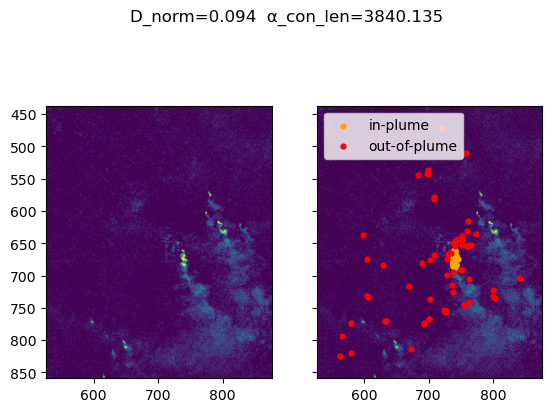

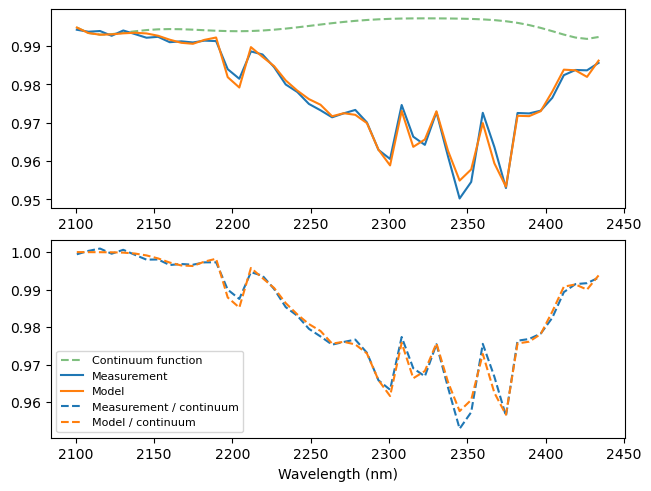

In [21]:
if results:
    best_idx = min(results, key=lambda k: results[k]["D_norm"])
    print(f"Polygon {best_idx}: D_norm={results[best_idx]['D_norm']:.3f}")
    plume_vetting.plot_vetting(results[best_idx], cmf_values=wmf_ppmxm.values)

The marshsi package and tutorials are released under a [Creative Commons non-commercial Share-Alike licence](https://creativecommons.org/licenses/by-nc-sa/4.0/legalcode.txt). For using the codes in comercial pipelines written consent by the authors must be provided.

 If you find this work useful please cite:
```
@article{ruzicka_starcop_2023,
	title = {Semantic segmentation of methane plumes with hyperspectral machine learning models},
	volume = {13},
	issn = {2045-2322},
	url = {https://www.nature.com/articles/s41598-023-44918-6},
	doi = {10.1038/s41598-023-44918-6},
	number = {1},
	journal = {Scientific Reports},
	author = {Růžička, Vít and Mateo-Garcia, Gonzalo and Gómez-Chova, Luis and Vaughan, Anna, and Guanter, Luis and Markham, Andrew},
	month = nov,
	year = {2023},
	pages = {19999}
}
```